# ZAJECIA 4 – BAZY DANYCH, SREDNIA KROCZACA I REGRESJA LOGISTYCZNA
**Wydzial Zarzadzania UW**

Na tych zajeciach nauczymy sie:
- pobierac dane gieldowe z serwisu **Yahoo Finance** (`yfinance`)
- przechowywac dane w lokalnej bazie **SQLite** i odpytywac ja za pomoca **SQL**
- budowac i wizualizowac **srednia kroczaca** (Moving Average)
- przeprowadzac kluczowa **inzynierie cech**: zamieniac niestacjonarne ceny na stacjonarne stopy zwrotu
- stosowac **regresje logistyczna** do prognozowania kierunku zmiany kursu w oknie nastepnego tygodnia handlowego

---
## 11. POBIERANIE DANYCH Z YAHOO FINANCE – BIBLIOTEKA yfinance

Do tej pory korzystalismy ze stooq.pl i polskich spolek. Teraz przejdziemy na **amerykanski rynek akcji**
i uzyje my biblioteki `yfinance`, ktora pozwala wygodnie pobierac dane z Yahoo Finance.

Skupimy sie na **10 spolkach o najwiekszej kapitalizacji z indeksu NASDAQ 100**.

In [1]:
# Instalacja (jesli potrzebna)
# !pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# 10 spolek NASDAQ 100 o najwiekszej kapitalizacji (stan ~2025)
nasdaq_top10 = {
    'AAPL':  'Apple',
    'MSFT':  'Microsoft',
    'NVDA':  'NVIDIA',
    'AMZN':  'Amazon',
    'META':  'Meta Platforms',
    'GOOGL': 'Alphabet',
    'AVGO':  'Broadcom',
    'TSLA':  'Tesla',
    'COST':  'Costco',
    'NFLX':  'Netflix'
}

tickers = list(nasdaq_top10.keys())
print('Tickery do pobrania:', tickers)

Tickery do pobrania: ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'META', 'GOOGL', 'AVGO', 'TSLA', 'COST', 'NFLX']


### 11.1 Pobieranie danych za pomoca yfinance

In [5]:
# Pobieramy dzienne ceny zamkniecia za okres 2020-2025
data_od = '2020-01-01'
data_do = '2025-12-31'

df_all = yf.download(
    tickers=tickers,
    start=data_od,
    end=data_do,
    group_by='ticker',  # dane pogrupowane po tickerze
    auto_adjust=True     # ceny skorygowane o splity / dywidendy
)

print('Ksztalt danych:', df_all.shape)
df_all.head()

[*********************100%***********************]  10 of 10 completed

Ksztalt danych: (1507, 50)


Ticker           AMZN                                                  AVGO  \
Price            Open       High        Low      Close    Volume       Open   
Date                                                                          
2020-01-02  93.750000  94.900497  93.207497  94.900497  80580000  27.413936   
2020-01-03  93.224998  94.309998  93.224998  93.748497  75288000  27.258541   
2020-01-06  93.000000  95.184502  93.000000  95.143997  81236000  26.686772   
2020-01-07  95.224998  95.694504  94.601997  95.343002  80898000  27.064515   
2020-01-08  94.902000  95.550003  94.321999  94.598503  70160000  26.869638   

Ticker                                                 ...       TSLA  \
Price            High        Low      Close    Volume  ...       Open   
Date                                                   ...              
2020-01-02  27.686943  27.242235  27.677498  20329000  ...  28.299999   
2020-01-03  27.472310  26.964073  26.973516  22870000  ...  29.366667   
2020-01-06  26.950335  26.582034  26.933165  20789000  ...  29.364668   
2020-01-07  27.178698  26.806963  26.840445  18565000  ...  30.760000   
2020-01-08  26.913423  26.477299  26.505630  31979000  ...  31.580000   

Ticker                                                        META  \
Price            High        Low      Close     Volume        Open   
Date                                                                 
2020-01-02  28.713333  28.114000  28.684000  142981500  205.140155   
2020-01-03  30.266666  29.128000  29.534000  266677500  205.596588   
2020-01-06  30.104000  29.333332  30.102667  151995000  205.090556   
2020-01-07  31.441999  30.224001  31.270666  268231500  211.162925   
2020-01-08  33.232666  31.215334  32.809334  467164500  211.341504   

Ticker                                                    
Price             High         Low       Close    Volume  
Date                                                      
2020-01-02  208.156477  204.663897  208.146561  12077100  
2020-01-03  208.761737  205.338603  207.045212  11188400  
2020-01-06  211.123217  204.911965  210.944626  17058900  
2020-01-07  212.909216  210.101249  211.401047  14912400  
2020-01-08  214.556282  210.954542  213.544220  13475000  

[5 rows x 50 columns]

### 11.2 Transformacja do formatu dlugiego (long format)

yfinance zwraca dane w formacie szerokim (kolumny = ticker × OHLCV).
Przeksztalcimy je do formatu dlugiego – jednego wiersza na kazdy dzien × ticker.

In [6]:
frames = []
for ticker in tickers:
    tmp = df_all[ticker].copy()
    tmp['Ticker'] = ticker
    tmp['Company'] = nasdaq_top10[ticker]
    tmp.index.name = 'Date'
    tmp = tmp.reset_index()
    frames.append(tmp)

df = pd.concat(frames, ignore_index=True)

# Usuwamy wiersze bez ceny zamkniecia
df = df.dropna(subset=['Close'])

print(f'Laczna liczba wierszy: {len(df)}')
print(f'Unikalne tickery:      {df["Ticker"].nunique()}')
df.head()

Laczna liczba wierszy: 15070
Unikalne tickery:      10


Price,Date,Open,High,Low,Close,Volume,Ticker,Company
0,2020-01-02,71.409770,72.460769,71.156667,72.400505,135480400,AAPL,Apple
1,2020-01-03,71.629153,72.455966,71.472469,71.696648,146322800,AAPL,Apple
2,2020-01-06,70.819208,72.306506,70.568510,72.267937,118387200,AAPL,Apple
3,2020-01-07,72.277571,72.533087,71.708687,71.928047,108872000,AAPL,Apple
4,2020-01-08,71.631559,73.386431,71.631559,73.085114,132079200,AAPL,Apple


In [7]:
df.tail()

Price,Date,Open,High,Low,Close,Volume,Ticker,Company
15065,2025-12-23,93.400002,93.809998,91.330002,93.500000,25896200,NFLX,Netflix
15066,2025-12-24,93.110001,93.680000,92.669998,93.639999,12427900,NFLX,Netflix
15067,2025-12-26,93.480003,94.690002,93.269997,94.470001,22068300,NFLX,Netflix
15068,2025-12-29,93.989998,94.970001,93.629997,94.150002,24493700,NFLX,Netflix
15069,2025-12-30,93.519997,93.989998,93.339996,93.779999,23422000,NFLX,Netflix


---
## 12. ZAPIS DANYCH DO BAZY SQLite

**SQLite** to lekka, plikowa baza danych wbudowana w Pythona (modul `sqlite3`).
Nie wymaga instalacji serwera – cala baza to pojedynczy plik `.db`.

Uzycie bazy danych w analizie danych pozwala:
- trwale przechowywac duze zbiory danych,
- odpytywac je za pomoca jezyka **SQL**,
- latwo filtrowac, laczyc i agregowac dane.

In [ ]:
import sqlite3

# Tworzymy (lub otwieramy) plik bazy danych
conn = sqlite3.connect('nasdaq_top10.db')

# Zapisujemy DataFrame do tabeli SQL
df.to_sql('prices', conn, if_exists='replace', index=False)

print('Tabela "prices" zapisana w pliku nasdaq_top10.db')

Tabela "prices" zapisana w pliku nasdaq_top10.db


### 12.1 Zapytania SQL – odczyt danych z bazy

In [9]:
# Wczytanie calej tabeli
df_sql = pd.read_sql('SELECT * FROM prices', conn)
print(f'Wierszy: {len(df_sql)}, Kolumn: {len(df_sql.columns)}')
df_sql.head()

Wierszy: 15070, Kolumn: 8


,Date,Open,High,Low,Close,Volume,Ticker,Company
0,2020-01-02 00:00:00,71.409770,72.460769,71.156667,72.400505,135480400,AAPL,Apple
1,2020-01-03 00:00:00,71.629153,72.455966,71.472469,71.696648,146322800,AAPL,Apple
2,2020-01-06 00:00:00,70.819208,72.306506,70.568510,72.267937,118387200,AAPL,Apple
3,2020-01-07 00:00:00,72.277571,72.533087,71.708687,71.928047,108872000,AAPL,Apple
4,2020-01-08 00:00:00,71.631559,73.386431,71.631559,73.085114,132079200,AAPL,Apple


In [10]:
# Filtrowanie SQL – tylko Apple, rok 2024
query = """
SELECT Date, Close, Volume
FROM prices
WHERE Ticker = 'AAPL'
  AND Date >= '2024-01-01'
  AND Date <  '2025-01-01'
ORDER BY Date
"""

df_aapl_2024 = pd.read_sql(query, conn)
print(f'Wierszy AAPL 2024: {len(df_aapl_2024)}')
df_aapl_2024.head()

Wierszy AAPL 2024: 252


,Date,Close,Volume
0,2024-01-02 00:00:00,183.731323,82488700
1,2024-01-03 00:00:00,182.355591,58414500
2,2024-01-04 00:00:00,180.039642,71983600
3,2024-01-05 00:00:00,179.317154,62379700
4,2024-01-08 00:00:00,183.652130,59144500


In [11]:
# Agregacja SQL – srednia cena zamkniecia i laczny wolumen per spolka
query_agg = """
SELECT Ticker,
       Company,
       ROUND(AVG(Close), 2) AS avg_close,
       SUM(Volume)          AS total_volume,
       COUNT(*)             AS n_days
FROM prices
GROUP BY Ticker
ORDER BY avg_close DESC
"""

df_agg = pd.read_sql(query_agg, conn)
df_agg

,Ticker,Company,avg_close,total_volume,n_days
0,COST,Costco,578.66,3422603300,1507
1,META,Meta Platforms,360.17,32981928500,1507
2,MSFT,Microsoft,315.32,41559068000,1507
3,TSLA,Tesla,237.09,182300346800,1507
4,AAPL,Apple,164.72,127455012600,1507
5,AMZN,Amazon,158.43,97244021300,1507
6,GOOGL,Alphabet,133.31,50673556500,1507
7,AVGO,Broadcom,103.38,37888071700,1507
8,NVDA,NVIDIA,57.49,617107826600,1507
9,NFLX,Netflix,57.42,89839647000,1507


In [ ]:
### ZADANIE 1 ###
# Napisz zapytanie SQL, ktore zwroci 5 dni o najwiekszym wolumenie
# dla spolki NVDA (NVIDIA). Wyswietl kolumny: Date, Close, Volume.

# Twoj kod tutaj:


In [12]:
# Rozwiazanie:
query_z1 = """
SELECT Date, Close, Volume
FROM prices
WHERE Ticker = 'NVDA'
ORDER BY Volume DESC
LIMIT 5
"""
pd.read_sql(query_z1, conn)

,Date,Close,Volume
0,2023-05-25 00:00:00,37.946407,1543911000
1,2020-09-04 00:00:00,12.582704,1463684000
2,2020-09-14 00:00:00,12.831669,1201744000
3,2022-09-01 00:00:00,13.914613,1178865000
4,2020-05-27 00:00:00,8.491955,1175892000


---
## 13. SREDNIA KROCZACA (Moving Average)

Srednia kroczaca to jeden z najpopularniejszych wskaznikow analizy technicznej.
Wygladza krotkoterminowy szum cenowy i pomaga identyfikowac trend.

Stworzymy **funkcje**, ktora:
1. obliczy srednie kroczace dla wybranego instrumentu,
2. narysuje wykres ceny z naniesionymi srednimi.

In [13]:
def srednia_kroczaca(df, ticker, windows=[20, 50, 200]):
    """
    Oblicza srednie kroczace i rysuje wykres.

    Parametry:
    ----------
    df      : DataFrame z kolumnami Date, Close, Ticker
    ticker  : str – symbol spolki (np. 'AAPL')
    windows : list[int] – dlugosci okien srednich kroczacych
    """
    # Filtrujemy dane dla wybranego tickera
    mask = df['Ticker'] == ticker
    data = df.loc[mask].copy().sort_values('Date')

    # Obliczamy kazda srednia kroczaca
    for w in windows:
        col_name = f'SMA_{w}'
        data[col_name] = data['Close'].rolling(window=w).mean()

    # --- Wizualizacja ---
    fig, ax = plt.subplots(figsize=(13, 6))

    ax.plot(data['Date'], data['Close'],
            label='Cena zamkniecia', color='black', linewidth=1, alpha=0.7)

    kolory = ['#e74c3c', '#2ecc71', '#3498db']
    for w, kolor in zip(windows, kolory):
        col_name = f'SMA_{w}'
        ax.plot(data['Date'], data[col_name],
                label=f'SMA {w}', color=kolor, linewidth=1.5)

    company = data['Company'].iloc[0]
    ax.set_title(f'{company} ({ticker}) – cena i srednie kroczace',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Data')
    ax.set_ylabel('Cena (USD)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return data

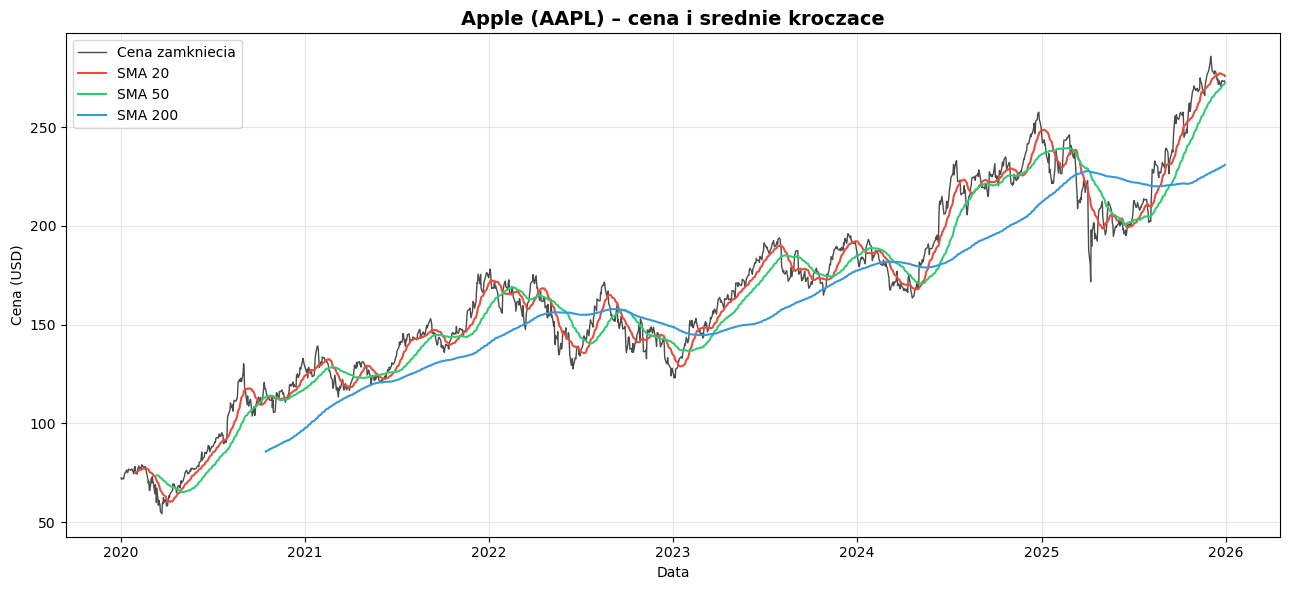

In [14]:
# Wywolanie dla Apple
df_aapl_ma = srednia_kroczaca(df, 'AAPL')

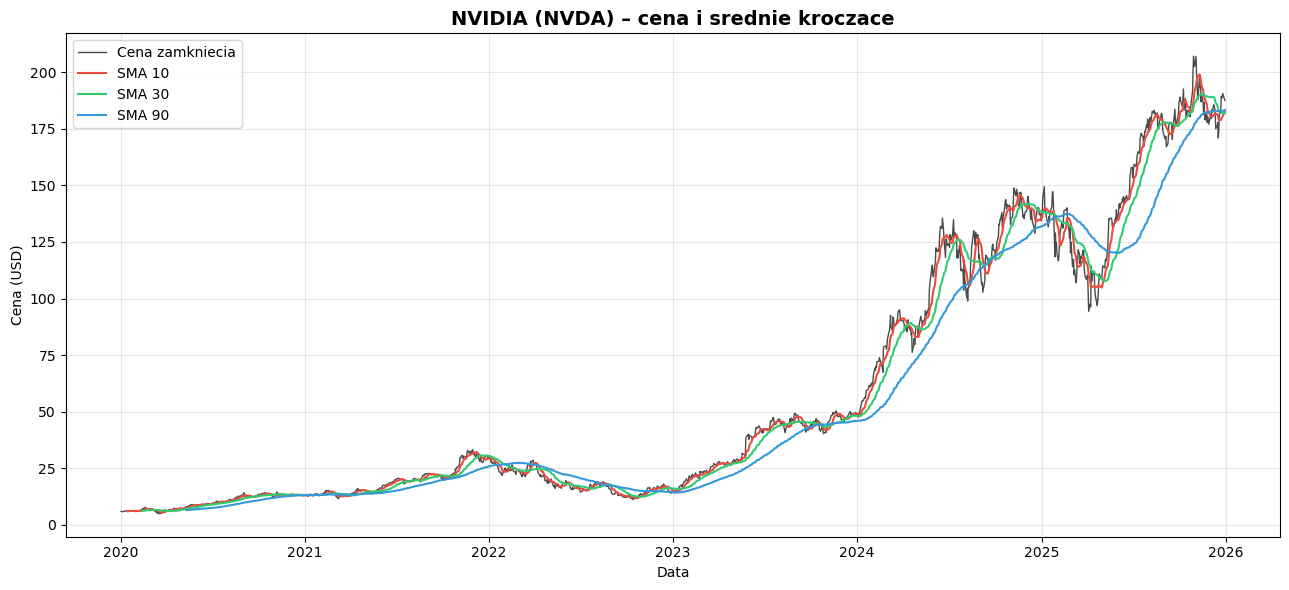

In [15]:
# Wywolanie dla NVIDIA z innymi oknami
df_nvda_ma = srednia_kroczaca(df, 'NVDA', windows=[10, 30, 90])

In [ ]:
### ZADANIE 2 ###
# Wywolaj funkcje srednia_kroczaca dla dowolnej innej spolki
# z naszej listy nasdaq_top10. Uzyj domyslnych okien.

# Twoj kod tutaj:


---
### 13.2 Wyrazenia lambda – krotkie funkcje anonimowe

Wyrazenie `lambda` to sposob na zdefiniowanie **malej, jednorazowej funkcji** bez nadawania jej nazwy.
Zamiast pisac pelna definicje z `def`, mozemy uzyc jednolinijkowej formy:

```python
lambda argumenty: wyrazenie
```

Lambdy sa szczegolnie przydatne w polaczeniu z metodami takimi jak `.apply()`, `.transform()` czy `.map()`,
gdzie potrzebujemy przekazac prosta operacje jako argument.

In [16]:
# Klasyczna funkcja
def podwoj(x):
    return x * 2

# To samo jako lambda
podwoj_lambda = lambda x: x * 2

print(podwoj(5))         # 10
print(podwoj_lambda(5))  # 10

10
10


In [21]:
# Lambda w praktyce – zastosowanie z pandas
import pandas as pd

ceny = pd.Series([100, 200, 150, 300], name='cena')

# .apply() z lambda – przeliczenie na tysiace
print(ceny.apply(lambda x: x / 1000))

0    0.10
1    0.20
2    0.15
3    0.30
Name: cena, dtype: float64


In [22]:
# Lambda w praktyce – zastosowanie z pandas
import pandas as pd

ceny = pd.Series([100, 200, 150, 300], name='cena')

# .apply() z lambda – przeliczenie na tysiace
print(ceny.apply(lambda x: x / 1000))

0    0.10
1    0.20
2    0.15
3    0.30
Name: cena, dtype: float64


### 13.3 Metoda .transform() w groupby

`.transform()` oblicza wynik **per grupa**, ale zwraca wartosc dla **kazdego wiersza** (zachowuje rozmiar oryginalnej tabeli). Rozni sie tym od `.agg()`, ktory zwraca tylko jedna wartosc per grupa.

Uzywamy go, gdy chcemy dopisac statystyke grupowa z powrotem do DataFrame – wlasnie dlatego w sekcji 14 zastosujemy `groupby('Ticker').transform(lambda ...)`, zeby policzyc stopy zwrotu osobno per spolka.

In [24]:
import pandas as pd

sprzedaz = pd.DataFrame({
    'sklep':    ['Warszawa', 'Warszawa', 'Warszawa', 'Krakow', 'Krakow', 'Krakow'],
    'miesiac':  ['sty', 'lut', 'mar', 'sty', 'lut', 'mar'],
    'przychod': [100, 150, 120, 200, 180, 220]
})

# .agg() – jedna wartosc per grupa (2 wiersze)
print('.agg() – wynik zagregowany:')
print(sprzedaz.groupby('sklep')['przychod'].agg('mean'))

# .transform() – srednia przypisana do KAZDEGO wiersza (6 wierszy)
sprzedaz['srednia_sklepu'] = sprzedaz.groupby('sklep')['przychod'].transform('mean')

print('\n.transform() – wynik dopisany do tabeli:')
sprzedaz

.agg() – wynik zagregowany:
sklep
Krakow      200.000000
Warszawa    123.333333
Name: przychod, dtype: float64

.transform() – wynik dopisany do tabeli:


,sklep,miesiac,przychod,srednia_sklepu
0,Warszawa,sty,100,123.333333
1,Warszawa,lut,150,123.333333
2,Warszawa,mar,120,123.333333
3,Krakow,sty,200,200.000000
4,Krakow,lut,180,200.000000
5,Krakow,mar,220,200.000000


In [23]:
# Lambda z .transform() w groupby – wstep do sekcji 14
#
# .transform() zwraca Series o tym samym rozmiarze co dane wejsciowe
# (w przeciwienstwie do .agg(), ktory zwraca zagregowany wynik)

df_tmp = pd.DataFrame({
    'grupa':   ['A', 'A', 'A', 'B', 'B', 'B'],
    'wartosc': [10,  20,  30,  100, 200, 300]
})

# Srednia per grupa – przypisana do kazdego wiersza
df_tmp['srednia_grupy'] = df_tmp.groupby('grupa')['wartosc'].transform(
    lambda x: x.mean()
)

# Roznica od sredniej grupy
df_tmp['odchylenie'] = df_tmp.groupby('grupa')['wartosc'].transform(
    lambda x: x - x.mean()
)

df_tmp

,grupa,wartosc,srednia_grupy,odchylenie
0,A,10,20.0,-10.0
1,A,20,20.0,0.0
2,A,30,20.0,10.0
3,B,100,200.0,-100.0
4,B,200,200.0,0.0
5,B,300,200.0,100.0


In [20]:
# Przyklad bliski naszemu uzyciu – logarytm ilorazu kolejnych wartosci
import numpy as np

df_tmp['log_zmiana'] = df_tmp.groupby('grupa')['wartosc'].transform(
    lambda x: np.log(x / x.shift(1))
)

df_tmp

,grupa,wartosc,srednia_grupy,odchylenie,log_zmiana
0,A,10,20.0,-10.0,NaN
1,A,20,20.0,0.0,0.693147
2,A,30,20.0,10.0,0.405465
3,B,100,200.0,-100.0,NaN
4,B,200,200.0,0.0,0.693147
5,B,300,200.0,100.0,0.405465


---
## 14. INZYNIERIA CECH – STOPY ZWROTU

### Dlaczego nie modelujemy surowych cen?

Ceny akcji sa **niestacjonarne** – ich srednia i wariancja zmieniaja sie w czasie.
Wiekszość modeli uczenia maszynowego (w tym regresja logistyczna) zaklada,
ze dane wejsciowe sa **stacjonarne**.

Logarytmiczne stopy zwrotu:
- oscyluja wokol zera (stacjonarnosc),
- dobrze przyblizaja procentowe zmiany dla malych wartosci.

In [25]:
# Pracujemy na danych wczytanych z SQLite
df_sql['Date'] = pd.to_datetime(df_sql['Date'])

# Obliczamy dzienne logarytmiczne stopy zwrotu per ticker
df_sql = df_sql.sort_values(['Ticker', 'Date'])
df_sql['log_return'] = df_sql.groupby('Ticker')['Close'].transform(
    lambda x: np.log(x / x.shift(1))
)

# Usuwamy pierwszy wiersz kazdej spolki (NaN)
df_sql = df_sql.dropna(subset=['log_return'])

print(df_sql[['Date', 'Ticker', 'Close', 'log_return']].head(10))

         Date Ticker      Close  log_return
1  2020-01-03   AAPL  71.696648   -0.009769
2  2020-01-06   AAPL  72.267937    0.007937
3  2020-01-07   AAPL  71.928047   -0.004714
4  2020-01-08   AAPL  73.085114    0.015958
5  2020-01-09   AAPL  74.637505    0.021018
6  2020-01-10   AAPL  74.806236    0.002258
7  2020-01-13   AAPL  76.404419    0.021139
8  2020-01-14   AAPL  75.372726   -0.013595
9  2020-01-15   AAPL  75.049675   -0.004295
10 2020-01-16   AAPL  75.989807    0.012449


### 14.1 Porownanie: cena vs stopa zwrotu

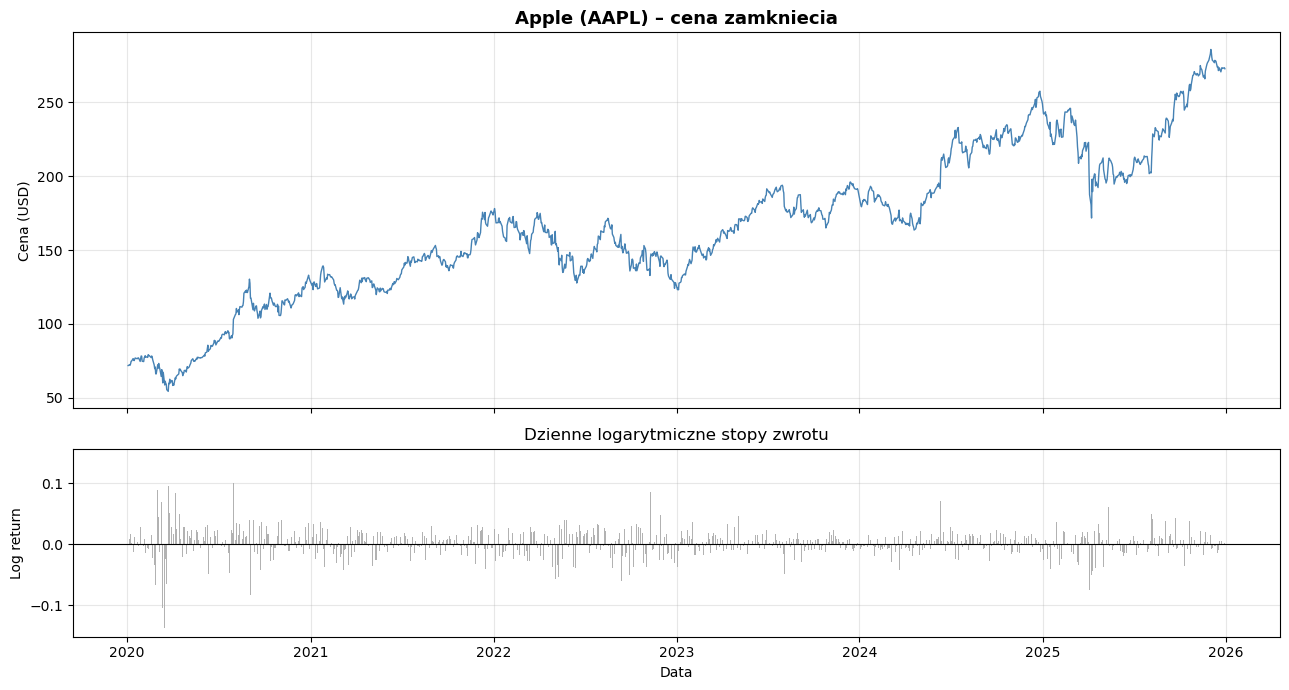

In [26]:
# Wizualizacja – cena vs log return dla AAPL
aapl = df_sql[df_sql['Ticker'] == 'AAPL'].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(aapl['Date'], aapl['Close'], color='steelblue', linewidth=1)
ax1.set_title('Apple (AAPL) – cena zamkniecia', fontsize=13, fontweight='bold')
ax1.set_ylabel('Cena (USD)')
ax1.grid(True, alpha=0.3)

ax2.bar(aapl['Date'], aapl['log_return'], color='gray', alpha=0.6, width=1)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Dzienne logarytmiczne stopy zwrotu', fontsize=12)
ax2.set_ylabel('Log return')
ax2.set_xlabel('Data')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Statystyki opisowe stop zwrotu per spolka
stats = df_sql.groupby('Ticker')['log_return'].describe().round(4)
stats

---
## 15. REGRESJA LOGISTYCZNA – PROGNOZOWANIE KIERUNKU ZMIANY

**Cel:** Na podstawie historycznych stop zwrotu przewidziec,
czy w ciagu **nastepnych 5 dni handlowych** (1 tydzien) kurs wzrosnie czy spadnie.

Jest to **problem klasyfikacji binarnej**:
- klasa **1** = wzrost (stopa zwrotu z 5 dni > 0),
- klasa **0** = spadek (stopa zwrotu z 5 dni ≤ 0).

**Regresja logistyczna** to podstawowy model klasyfikacji, ktory estymuje prawdopodobienstwo
przynaleznosci do klasy 1 za pomoca funkcji sigmoidalnej

https://miroslawmamczur.pl/jak-dziala-regresja-logistyczna/

### 15.1 Przygotowanie cech (features)

In [ ]:
def przygotuj_cechy(df, ticker, forward_window=5):
    """
    Przygotowuje cechy i zmienna docelowa dla jednej spolki.

    Cechy (features):
      - log_return           : dzisiejsza stopa zwrotu
      - rolling_mean_5       : srednia stop zwrotu z ostatnich 5 dni
      - rolling_std_5        : odchylenie std. stop zwrotu z 5 dni
      - rolling_mean_20      : srednia stop zwrotu z ostatnich 20 dni
      - rolling_std_20       : odchylenie std. stop zwrotu z 20 dni

    Zmienna docelowa (target):
      - target : 1 jesli suma log_return w nastepnych `forward_window` dniach > 0, inaczej 0
    """
    data = df[df['Ticker'] == ticker].copy().sort_values('Date')

    # Cechy oparte na kroczacych statystykach stop zwrotu
    data['rolling_mean_5']  = data['log_return'].rolling(5).mean()
    data['rolling_std_5']   = data['log_return'].rolling(5).std()
    data['rolling_mean_20'] = data['log_return'].rolling(20).mean()
    data['rolling_std_20']  = data['log_return'].rolling(20).std()

    # Zmienna docelowa – kierunek w nastepnym tygodniu na podstawie forward_return - zsumowane 5 kolejnych stóp zwrotu. Jeżeli są większe od 0 - to target = 1 (nastąpił wzrost w kolejnych 5 dniach)
    data['forward_return'] = data['log_return'].rolling(forward_window).sum().shift(-forward_window)
    data['target'] = (data['forward_return'] > 0).astype(int)

    # Usuwamy wiersze z brakujacymi wartosciami
    data = data.dropna()

    return data

# Przyklad – Apple
df_feat = przygotuj_cechy(df_sql, 'AAPL')
print(f'Wierszy po inzynierii cech: {len(df_feat)}')
df_feat[['Date', 'Close', 'log_return', 'rolling_mean_5',
          'rolling_std_5', 'forward_return','target']].tail(10)

Wierszy po inzynierii cech: 1482


,Date,Close,log_return,rolling_mean_5,rolling_std_5,forward_return,target
1492,2025-12-09,276.920868,-0.002558,-0.006398,0.003861,-0.009315,0
1493,2025-12-10,278.519379,0.005756,-0.003816,0.006585,-0.025209,0
1494,2025-12-11,277.770081,-0.002694,-0.001911,0.004637,-0.021229,0
1495,2025-12-12,278.019867,0.000899,-0.000359,0.003785,-0.016705,0
1496,2025-12-15,273.853729,-0.015098,-0.002739,0.007717,-0.011521,0
1497,2025-12-16,274.353271,0.001822,-0.001863,0.007986,-0.008227,0
1498,2025-12-17,271.585876,-0.010138,-0.005042,0.007332,0.007221,1
1499,2025-12-18,271.935547,0.001287,-0.004246,0.007849,0.004436,1
1500,2025-12-19,273.414185,0.005423,-0.003341,0.008794,0.000329,1
1501,2025-12-22,270.716675,-0.009915,-0.002304,0.007227,0.007757,1


In [31]:
# Rozklad klas
print('Rozklad zmiennej target (Apple):')
print(df_feat['target'].value_counts())
print()
print(f"Procent wzrostow: {df_feat['target'].mean()*100:.1f}%")

Rozklad zmiennej target (Apple):
target
1    836
0    646
Name: count, dtype: int64

Procent wzrostow: 56.4%


### 15.2 Podzial na zbior treningowy i testowy

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Cechy i target
feature_cols = ['log_return', 'rolling_mean_5', 'rolling_std_5',
                'rolling_mean_20', 'rolling_std_20']

X = df_feat[feature_cols]
y = df_feat['target']

# Podzial chronologiczny – NIE losowy! (dane czasowe)
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Zbior treningowy: {len(X_train)} wierszy')
print(f'Zbior testowy:    {len(X_test)} wierszy')

Zbior treningowy: 1185 wierszy
Zbior testowy:    297 wierszy


> **Uwaga:** Przy danych czasowych **nie** stosujemy losowego podzialu (`shuffle=True`),
> bo prowadziloby to do **wycieku informacji z przyszlosci** (data leakage).
> Zamiast tego dzielimy dane chronologicznie: pierwszych 80% to trening, reszta to test.

### 15.3 Trenowanie modelu

In [33]:
# Standaryzacja cech (wazna dla regresji logistycznej)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # uzywamy parametrow z TRENINGU

# Trenujemy regresje logistyczna
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print('Model wytrenowany!')
print(f'Wspolczynniki: {dict(zip(feature_cols, model.coef_[0].round(4)))}')
print(f'Intercept:     {model.intercept_[0]:.4f}')

Model wytrenowany!
Wspolczynniki: {'log_return': np.float64(0.0007), 'rolling_mean_5': np.float64(0.0106), 'rolling_std_5': np.float64(-0.1567), 'rolling_mean_20': np.float64(0.1089), 'rolling_std_20': np.float64(0.0835)}
Intercept:     0.2749


### 15.4 Ewaluacja modelu

In [34]:
# Predykcja na zbiorze testowym
y_pred = model.predict(X_test_scaled)

# Dokladnosc
acc = accuracy_score(y_test, y_pred)
print(f'Dokladnosc (accuracy): {acc:.4f}')
print()

# Raport klasyfikacji
print('Raport klasyfikacji:')
print(classification_report(y_test, y_pred, target_names=['Spadek (0)', 'Wzrost (1)']))

Dokladnosc (accuracy): 0.5253

Raport klasyfikacji:
              precision    recall  f1-score   support

  Spadek (0)       0.27      0.03      0.05       134
  Wzrost (1)       0.54      0.93      0.68       163

    accuracy                           0.53       297
   macro avg       0.40      0.48      0.37       297
weighted avg       0.42      0.53      0.40       297



### 15.5 Jak czytac raport klasyfikacji?

**Accuracy** (dokladnosc) – jaki procent **wszystkich** predykcji byl trafny:

$$Accuracy = \frac{\text{poprawne predykcje}}{\text{wszystkie predykcje}} = \frac{TP + TN}{TP + TN + FP + FN}$$

**Precision** (precyzja) – jesli model powiedzial „wzrost", to jak czesto mial racje:

$$Precision = \frac{TP}{TP + FP}$$

**Recall** (czulosc) – sposrod wszystkich rzeczywistych wzrostow, ile model wylapał:

$$Recall = \frac{TP}{TP + FN}$$

gdzie: **TP** = trafnie przewidziany wzrost, **TN** = trafnie przewidziany spadek, **FP** = falszywy alarm (model powiedzial wzrost, a byl spadek), **FN** = pominiety wzrost (model powiedzial spadek, a byl wzrost).

> W naszym przykladzie model ma recall 0.93 dla klasy Wzrost, ale recall tylko 0.03 dla Spadek – oznacza to, ze model prawie zawsze przewiduje „wzrost" i rzadko rozpoznaje spadki. Accuracy 0.53 jest niewiele lepsze niz rzucanie moneta.

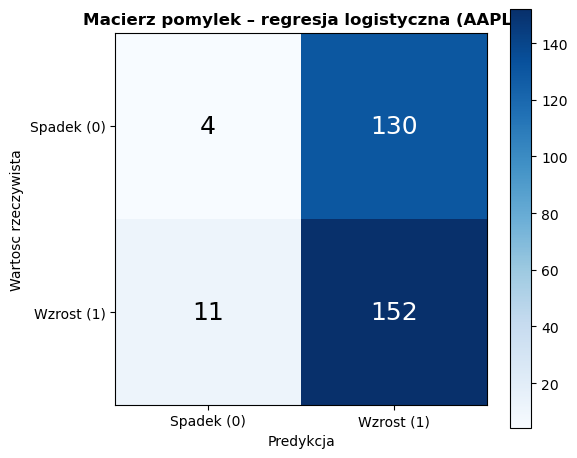

In [35]:
# Macierz pomylek (confusion matrix)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Etykiety
labels = ['Spadek (0)', 'Wzrost (1)']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predykcja')
ax.set_ylabel('Wartosc rzeczywista')
ax.set_title('Macierz pomylek – regresja logistyczna (AAPL)', fontweight='bold')

# Wartosci w komorach
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.colorbar(im)
plt.tight_layout()
plt.show()

### 15.5 Analiza prawdopodobienstwa

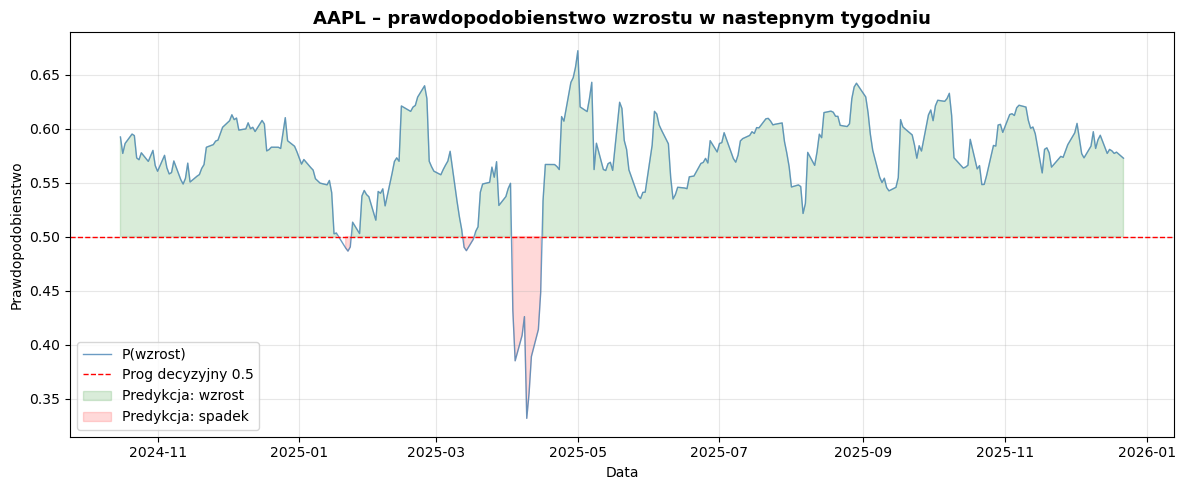

In [36]:
# Prawdopodobienstwo wzrostu (klasa 1) dla zbioru testowego
y_proba = model.predict_proba(X_test_scaled)[:, 1]

fig, ax = plt.subplots(figsize=(12, 5))

dates_test = df_feat['Date'].iloc[split_idx:].values

ax.plot(dates_test, y_proba, color='steelblue', linewidth=1, alpha=0.8, label='P(wzrost)')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Prog decyzyjny 0.5')
ax.fill_between(dates_test, y_proba, 0.5, where=(y_proba > 0.5),
                 alpha=0.15, color='green', label='Predykcja: wzrost')
ax.fill_between(dates_test, y_proba, 0.5, where=(y_proba <= 0.5),
                 alpha=0.15, color='red', label='Predykcja: spadek')

ax.set_title('AAPL – prawdopodobienstwo wzrostu w nastepnym tygodniu', fontsize=13, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Prawdopodobienstwo')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Zamkniecie polaczenia z baza danych

In [39]:
conn.close()
print('Polaczenie z baza SQLite zamkniete.')

Polaczenie z baza SQLite zamkniete.


---
### Podsumowanie zajec 4

Na dzisiejszych zajeciach:
1. Pobralismy dane gieldowe 10 najwiekszych spolek NASDAQ 100 za pomoca **yfinance**.
2. Zapisalismy dane w lokalnej bazie **SQLite** i odpytywalismy ja jezykiem **SQL**.
3. Stworzylis my **funkcje** do obliczania i wizualizowania **srednich kroczacych**.
4. Przeprowadzilismy kluczowa **inzynierie cech** – zamienilismy niestacjonarne ceny na stacjonarne **logarytmiczne stopy zwrotu**.
5. Zastosowalismy **regresje logistyczna** do prognozowania kierunku zmiany kursu w nastepnym tygodniu handlowym.
